# ProcureLens — Amendment Risk EDA

Reader-facing exploration of AusTender contracts awarded in 2019–2025. Source: `analytics_marts.fct_contracts`, built from the [AusTender OCDS API](https://api.tenders.gov.au/ocds).

## tl;dr

The executed 2019–2025 snapshot contains **445,029** unique contracts; **20.19%** were later amended upward. Open procurements have a **32.0%** observed rate, while contracts worth at least AUD 10m reach **50.1%**. The 2025 cohort is right-censored and should not be compared naively with mature cohorts. Detailed, reproducible calculations follow.

In [1]:
from IPython.display import Markdown, display

display(Markdown("*Headline figures are frozen to this executed data snapshot; the cells below recompute and validate each value.*"))

*Headline figures are frozen to this executed data snapshot; the cells below recompute and validate each value.*

## Context & Methods

The unit of analysis is one contracting process (`ocid`). Award-time attributes come from its initial `contract` release. The positive target requires at least one later release explicitly tagged `contractAmendment` whose contract value exceeds the initial value. All timestamps are interpreted as UTC.

### Key Assumptions

- The API's explicit `contractAmendment` tag is authoritative for amendment status.
- Initial signed date defines the model time split; later release dates only define the outcome.
- Contract values are lifetime maximum values, not annual expenditure.
- Agency-name similarity is a review queue, not automatic machinery-of-government entity resolution.

In [2]:
from difflib import SequenceMatcher
from itertools import combinations
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

from procurelens.config import get_settings

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
START_YEAR = 2019
END_YEAR = 2025
SOURCE_TABLE = "analytics_marts.fct_contracts"

## Data

### 1. Load the bounded award cohort

In [3]:
query = text(
    f"""
    select *
    from {SOURCE_TABLE}
    where award_date >= :start_date
      and award_date < :end_date
    """
)
engine = create_engine(get_settings().database_url, pool_pre_ping=True)
contracts = pd.read_sql_query(
    query,
    engine,
    params={
        "start_date": f"{START_YEAR}-01-01",
        "end_date": f"{END_YEAR + 1}-01-01",
    },
)
engine.dispose()
contracts["award_date"] = pd.to_datetime(contracts["award_date"], utc=True)
contracts["first_upward_amendment_date"] = pd.to_datetime(
    contracts["first_upward_amendment_date"], utc=True
)
contracts["last_amendment_date"] = pd.to_datetime(
    contracts["last_amendment_date"], utc=True
)
contracts["was_amended_up"] = contracts["was_amended_up"].astype(bool)
contracts.shape

(445029, 20)

### 2. Validate grain, target integrity and temporal coverage

In [4]:
quality_checks = pd.Series(
    {
        "rows": len(contracts),
        "distinct_ocids": contracts["ocid"].nunique(),
        "duplicate_ocids": contracts["ocid"].duplicated().sum(),
        "null_targets": contracts["was_amended_up"].isna().sum(),
        "negative_award_values": contracts["award_value_aud"].lt(0).sum(),
        "non_aud_awards": contracts["award_currency"].dropna().ne("AUD").sum(),
        "invalid_positive_targets": (
            contracts["was_amended_up"]
            & (
                contracts["amendment_count"].lt(1)
                | contracts["value_uplift_aud"].le(0)
                | contracts["first_upward_amendment_date"].isna()
            )
        ).sum(),
        "min_award_date": contracts["award_date"].min(),
        "max_award_date": contracts["award_date"].max(),
    },
    name="value",
)
assert quality_checks["rows"] == quality_checks["distinct_ocids"]
assert quality_checks["null_targets"] == 0
assert quality_checks["negative_award_values"] == 0
assert quality_checks["non_aud_awards"] == 0
assert quality_checks["invalid_positive_targets"] == 0
quality_checks.to_frame()

,value
rows,445029
distinct_ocids,445029
duplicate_ocids,0
null_targets,0
negative_award_values,0
non_aud_awards,0
invalid_positive_targets,0
min_award_date,2019-01-01 13:00:00+00:00
max_award_date,2025-12-30 22:56:09+00:00


In [5]:
null_profile = (
    contracts.isna().mean().mul(100).rename("null_pct").to_frame()
    .assign(non_null_rows=contracts.notna().sum())
    .sort_values("null_pct", ascending=False)
)
null_profile.head(15)

,null_pct,non_null_rows
first_upward_amendment_date,79.811,89847
last_amendment_date,78.161,97189
ocid,0.000,445029
initial_release_id,0.000,445029
value_uplift_aud,0.000,445029
amendment_count,0.000,445029
description_confidentiality,0.000,445029
value_confidentiality,0.000,445029
award_currency,0.000,445029
award_value_aud,0.000,445029


## Results

### 3. Target distribution and time stability

In [6]:
target_summary = pd.Series(
    {
        "contracts": len(contracts),
        "upward_amendments": int(contracts["was_amended_up"].sum()),
        "upward_amendment_rate_pct": contracts["was_amended_up"].mean() * 100,
    },
    name="value",
)
by_year = (
    contracts.assign(award_year=contracts["award_date"].dt.year)
    .groupby("award_year")["was_amended_up"]
    .agg(contracts="size", upward_amendments="sum", amendment_rate="mean")
)
display(target_summary.to_frame())
display(by_year)

,value
contracts,"445,029.000"
upward_amendments,"89,847.000"
upward_amendment_rate_pct,20.189


,contracts,upward_amendments,amendment_rate
award_year,,,
2019,64906,12238,0.189
2020,63761,13745,0.216
2021,70644,16133,0.228
2022,66440,13697,0.206
2023,58778,11556,0.197
2024,62522,13155,0.210
2025,57978,9323,0.161


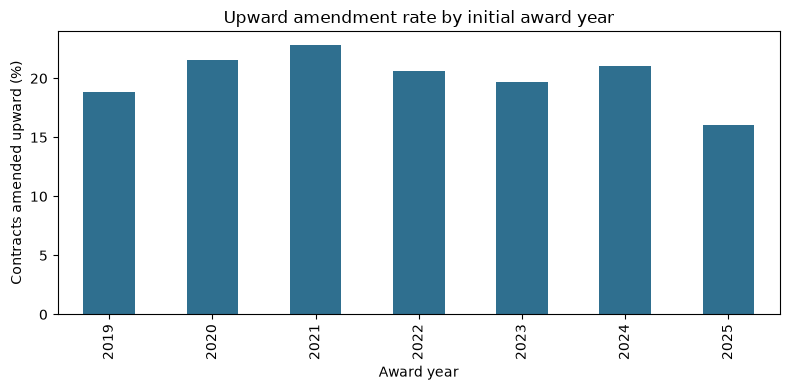

In [7]:
axis = by_year["amendment_rate"].mul(100).plot(
    kind="bar", figsize=(8, 4), color="#2f6f8f"
)
axis.set(
    title="Upward amendment rate by initial award year",
    xlabel="Award year",
    ylabel="Contracts amended upward (%)",
)
axis.set_ylim(bottom=0)
plt.tight_layout()

### 4. Segment rates: method, value band, agency and UNSPSC

In [8]:
contracts["value_band"] = pd.cut(
    contracts["award_value_aud"],
    bins=[-np.inf, 10_000, 80_000, 1_000_000, 10_000_000, np.inf],
    labels=["under_10k", "10k_to_80k", "80k_to_1m", "1m_to_10m", "10m_plus"],
    right=False,
)
contracts["unspsc_category"] = (
    contracts["unspsc_code"].astype("string").str.extract(r"^(\d{2})", expand=False)
)

def segment_summary(column, minimum_contracts=1):
    return (
        contracts.groupby(column, observed=True, dropna=False)
        .agg(
            contracts=("ocid", "size"),
            upward_amendments=("was_amended_up", "sum"),
            amendment_rate=("was_amended_up", "mean"),
            median_value_aud=("award_value_aud", "median"),
        )
        .query("contracts >= @minimum_contracts")
        .sort_values(["amendment_rate", "contracts"], ascending=False)
    )

display(segment_summary("procurement_method"))
display(segment_summary("value_band"))
display(segment_summary("agency", minimum_contracts=100).head(20))
display(segment_summary("unspsc_category", minimum_contracts=100).head(20))

,contracts,upward_amendments,amendment_rate,median_value_aud
procurement_method,,,,
open,195489,62652,0.320,"127,856.390"
selective,3169,636,0.201,"48,238.000"
limited,246371,26559,0.108,"33,000.000"


,contracts,upward_amendments,amendment_rate,median_value_aud
value_band,,,,
10m_plus,3541,1775,0.501,"21,911,735.510"
1m_to_10m,22463,8700,0.387,"2,000,000.000"
80k_to_1m,159488,50592,0.317,"211,354.220"
10k_to_80k,259537,28780,0.111,"25,203.010"


,contracts,upward_amendments,amendment_rate,median_value_aud
agency,,,,
Australian War Memorial,100,63,0.630,"803,325.060"
"Department of Health, Disability and Ageing",2532,1407,0.556,"300,150.000"
National Anti-Corruption Commission,240,108,0.450,"51,024.500"
Australian Transaction Reports and Analysis Centre,1015,428,0.422,"100,980.000"
Office of the eSafety Commissioner,555,231,0.416,"77,000.000"
NDIS Quality and Safeguards Commission,1521,623,0.410,"73,227.000"
Net Zero Economy Authority,113,45,0.398,"100,000.000"
Tourism Australia,152,60,0.395,"766,444.165"
Digital Transformation Agency,1479,564,0.381,"90,671.760"


,contracts,upward_amendments,amendment_rate,median_value_aud
unspsc_category,,,,
72,13536,4921,0.364,"139,721.935"
81,47780,15935,0.334,"158,400.000"
80,144497,43814,0.303,"85,000.000"
85,5279,1568,0.297,"69,300.000"
76,955,201,0.210,"40,932.960"
83,5207,1058,0.203,"46,257.400"
93,14935,2949,0.197,"51,625.200"
71,178,35,0.197,"114,945.835"
84,4620,899,0.195,"50,000.010"


### 5. Value and duration outliers

,rows
unparseable_start_dates,6
unparseable_end_dates,6


,award_value_aud,contract_duration_days
0.000,"10,000.000",0.000
0.010,"10,120.000",0.000
0.500,"57,571.800",216.958
0.950,"1,210,000.000","1,111.000"
0.990,"7,804,103.208","2,027.822"
1.000,"38,815,999,999.990","66,633.000"


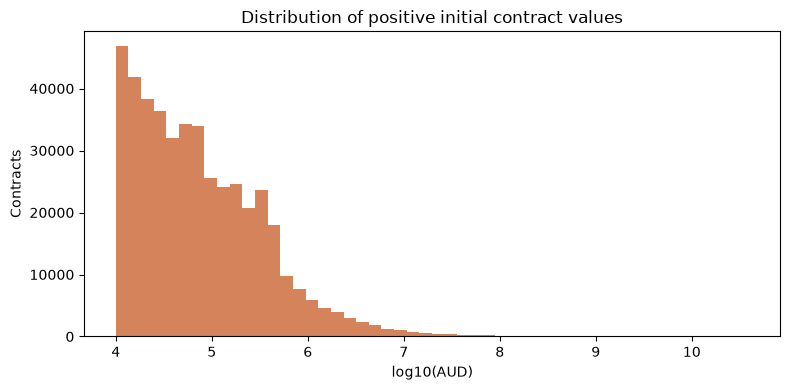

In [9]:
contract_start = pd.to_datetime(contracts["contract_start_date"], errors="coerce", utc=True)
contract_end = pd.to_datetime(contracts["contract_end_date"], errors="coerce", utc=True)
date_parse_quality = pd.Series(
    {
        "unparseable_start_dates": int(contracts["contract_start_date"].notna().sum() - contract_start.notna().sum()),
        "unparseable_end_dates": int(contracts["contract_end_date"].notna().sum() - contract_end.notna().sum()),
    },
    name="rows",
)
display(date_parse_quality.to_frame())
contracts["contract_duration_days"] = (contract_end - contract_start).dt.total_seconds() / 86_400
quantiles = contracts[["award_value_aud", "contract_duration_days"]].quantile(
    [0, 0.01, 0.5, 0.95, 0.99, 1]
)
display(quantiles)

positive_values = contracts.loc[contracts["award_value_aud"].gt(0), "award_value_aud"]
axis = np.log10(positive_values).plot.hist(bins=50, figsize=(8, 4), color="#d4835b")
axis.set(
    title="Distribution of positive initial contract values",
    xlabel="log10(AUD)",
    ylabel="Contracts",
)
plt.tight_layout()

### 6. Agency-name standardisation review

Exact punctuation/casing collisions and high-similarity pairs are review candidates. Similarity alone must not merge legally distinct or machinery-of-government successor entities.

In [10]:
agency_names = sorted(contracts["agency"].dropna().astype(str).unique())

def loose_agency_key(name):
    return re.sub(r"[^A-Z0-9]+", "", name.upper())

agency_variants = (
    pd.DataFrame({"agency": agency_names})
    .assign(loose_key=lambda frame: frame["agency"].map(loose_agency_key))
    .groupby("loose_key")["agency"]
    .agg(lambda values: sorted(set(values)))
    .loc[lambda values: values.map(len).gt(1)]
)

fuzzy_pairs = []
for left, right in combinations(agency_names, 2):
    score = SequenceMatcher(None, loose_agency_key(left), loose_agency_key(right)).ratio()
    if score >= 0.88 and loose_agency_key(left) != loose_agency_key(right):
        fuzzy_pairs.append((left, right, score))
fuzzy_review = pd.DataFrame(
    sorted(fuzzy_pairs, key=lambda item: item[2], reverse=True)[:30],
    columns=["agency_left", "agency_right", "similarity"],
)
display(agency_variants.to_frame(name="variants").head(30))
display(fuzzy_review)

,variants
loose_key,


,agency_left,agency_right,similarity
0,"Department of Infrastructure, Transport, Regio...","Department of Infrastructure, Transport, Regio...",0.969
1,"Department of Infrastructure, Transport, Regio...","Department of Infrastructure, Transport, Regio...",0.913
2,Asbestos Safety and Eradication Agency,Asbestos and Silica Safety and Eradication Agency,0.883
3,"Department of Infrastructure, Transport, Regio...","Department of Infrastructure, Transport, Regio...",0.883


## Takeaways

### 7. Render evidence-backed handoff values

In [11]:
method_rates = segment_summary("procurement_method")
value_rates = segment_summary("value_band")
highest_method = method_rates.index[0]
highest_band = value_rates.index[0]
summary = f"""
- **{len(contracts):,}** contracts were analysed at unique-`ocid` grain.
- **{contracts['was_amended_up'].mean():.2%}** were later amended upward.
- The highest observed procurement-method rate was **{highest_method}** at **{method_rates.iloc[0]['amendment_rate']:.2%}** (n={int(method_rates.iloc[0]['contracts']):,}).
- The highest observed value-band rate was **{highest_band}** at **{value_rates.iloc[0]['amendment_rate']:.2%}** (n={int(value_rates.iloc[0]['contracts']):,}).
- Award-value null rate was **{contracts['award_value_aud'].isna().mean():.2%}**; agency null rate was **{contracts['agency'].isna().mean():.2%}**.
- **{len(agency_variants):,}** punctuation/casing collision groups and **{len(fuzzy_review):,}** high-similarity agency pairs were queued for manual review.

These are descriptive associations, not causal effects. Recent cohorts have less time to accumulate amendments and should be monitored for right-censoring.
"""
display(Markdown(summary))


- **445,029** contracts were analysed at unique-`ocid` grain.
- **20.19%** were later amended upward.
- The highest observed procurement-method rate was **open** at **32.05%** (n=195,489).
- The highest observed value-band rate was **10m_plus** at **50.13%** (n=3,541).
- Award-value null rate was **0.00%**; agency null rate was **0.00%**.
- **0** punctuation/casing collision groups and **4** high-similarity agency pairs were queued for manual review.

These are descriptive associations, not causal effects. Recent cohorts have less time to accumulate amendments and should be monitored for right-censoring.
